# Hybrid ResGNN-UNet for Next-Day Wildfire Spread Prediction

This notebook implements a hybrid architecture combining:
- **Residual CNN Encoder** for spatial feature extraction
- **Graph Attention Network (GAT)** bottleneck for fire propagation modeling  
- **U-Net Decoder** with skip connections for pixel-level prediction

**Dataset:** Next Day Wildfire Spread (NDWS) - 18,445 samples, 64×64 tiles, 12 input channels

**Run all cells in order for proper train/val/test evaluation.**

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.8.0+cu126
CUDA version: 12.6


In [2]:
# Install PyTorch Geometric dependencies for PyTorch 2.6.0 + CUDA 12.4
!pip install protobuf==3.20.3
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.

In [3]:
# Install PyTorch Geometric and dependencies
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Data, Batch
import matplotlib.pyplot as plt

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.12/dist-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSsb
  import torch_geometric.typing
/usr/

Using device: cuda


In [4]:
# ============================================
# FIXED DATA LOADING WITH PROPER TRAIN/VAL/TEST SPLIT
# ============================================
import tensorflow as tf
import numpy as np
import os
import glob

# --- Setup Paths ---
INPUT_DIR = '/kaggle/input/next-day-wildfire-spread'
OUTPUT_DIR = '/kaggle/working/processed_data'

# Set to None for full dataset, or an integer to limit samples
MAX_SAMPLES = None  # Use full 18,445 dataset for paper results

# Create separate directories for splits
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

# --- Feature Definitions ---
IMG_SHAPE = [64, 64]

features_dict = {
    'elevation': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'th': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'vs': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'tmmn': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'tmmx': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'sph': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'pr': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'pdsi': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'NDVI': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'erc': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'population': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32),
    'FireMask': tf.io.FixedLenFeature(IMG_SHAPE, tf.float32)
}

def parse_tfrecord(example_proto):
    parsed_features = tf.io.parse_single_example(example_proto, features_dict)
    inputs = tf.stack([
        parsed_features['elevation'], parsed_features['th'], parsed_features['vs'],
        parsed_features['tmmn'], parsed_features['tmmx'], parsed_features['sph'],
        parsed_features['pr'], parsed_features['pdsi'], parsed_features['NDVI'],
        parsed_features['erc'], parsed_features['population'], parsed_features['PrevFireMask']
    ], axis=0)
    target = tf.expand_dims(parsed_features['FireMask'], axis=0)
    return tf.concat([inputs, target], axis=0)

# --- PROPER SPLIT: Following NDWS paper protocol ---
print(f"Searching for TFRecords in {INPUT_DIR}...")
tf_files = sorted(glob.glob(os.path.join(INPUT_DIR, '*.tfrecord')))
print(f"Found {len(tf_files)} TFRecord files.")

if tf_files:
    dataset = tf.data.TFRecordDataset(tf_files)
    dataset = dataset.map(parse_tfrecord)
    
    # Load all data (or limit if MAX_SAMPLES is set)
    all_data = []
    for i, data in enumerate(dataset):
        if MAX_SAMPLES is not None and i >= MAX_SAMPLES:
            break
        all_data.append(data)
    
    total = len(all_data)
    print(f"Total samples loaded: {total}")
    
    # Split ratios (approximating NDWS chronological split)
    train_end = int(0.75 * total)
    val_end = int(0.85 * total)
    
    splits = {
        'train': all_data[:train_end],
        'val': all_data[train_end:val_end],
        'test': all_data[val_end:]
    }
    
    for split_name, split_data in splits.items():
        print(f"Processing {split_name}: {len(split_data)} samples...")
        for i, data in enumerate(split_data):
            np.save(os.path.join(OUTPUT_DIR, split_name, f'sample_{i}.npy'), data.numpy())
    
    print("\n=== DATA SPLIT COMPLETE ===")
    print(f"Train: {len(splits['train'])} samples")
    print(f"Val:   {len(splits['val'])} samples") 
    print(f"Test:  {len(splits['test'])} samples")
else:
    print("Error: No TFRecord files found.")

2026-02-03 08:22:56.071256: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770106976.275800      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770106976.334619      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770106976.819966      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770106976.820027      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770106976.820030      24 computation_placer.cc:177] computation placer alr

Searching for TFRecords in /kaggle/input/next-day-wildfire-spread...
Found 19 TFRecord files.


I0000 00:00:1770106990.287192      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770106990.293218      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Total samples loaded: 18545
Processing train: 13908 samples...
Processing val: 1855 samples...
Processing test: 2782 samples...

=== DATA SPLIT COMPLETE ===
Train: 13908 samples
Val:   1855 samples
Test:  2782 samples


In [5]:
# ============================================
# DATASET CLASS WITH PROPER SPLITS
# ============================================

class WildfireDataset(Dataset):
    def __init__(self, data_dir, split='train'):
        split_dir = os.path.join(data_dir, split)
        self.files = sorted([os.path.join(split_dir, f) for f in os.listdir(split_dir) if f.endswith('.npy')])
        print(f"Loaded {len(self.files)} samples for {split} split")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        x = torch.tensor(data[:-1, :, :], dtype=torch.float32)
        y = torch.tensor(data[-1:, :, :], dtype=torch.float32)
        
        # Z-score normalization per sample
        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True)
        x = (x - mean) / (std + 1e-6)
        
        return x, y

# --- Initialize All DataLoaders ---
DATA_DIR = '/kaggle/working/processed_data'

train_dataset = WildfireDataset(DATA_DIR, split='train')
val_dataset = WildfireDataset(DATA_DIR, split='val')
test_dataset = WildfireDataset(DATA_DIR, split='test')

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"\nDataLoaders ready:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

Loaded 13908 samples for train split
Loaded 1855 samples for val split
Loaded 2782 samples for test split

DataLoaders ready:
  Train batches: 435
  Val batches:   58
  Test batches:  87


In [6]:
# ============================================
# TOPOLOGY GENERATOR (Grid to Graph)
# ============================================

def get_grid_topology(H, W, device):
    """
    Generates edge_index for an 8-connected grid of size HxW.
    Each pixel connects to its 8 neighbors (including diagonals).
    Returns tensor of shape [2, Num_Edges].
    """
    src_nodes = []
    dst_nodes = []

    # Offsets for 8 neighbors (including diagonals)
    offsets = [(-1, -1), (-1, 0), (-1, 1),
               ( 0, -1),          ( 0, 1),
               ( 1, -1), ( 1, 0), ( 1, 1)]

    for r in range(H):
        for c in range(W):
            curr_node = r * W + c
            for dr, dc in offsets:
                nr, nc = r + dr, c + dc
                if 0 <= nr < H and 0 <= nc < W:
                    neighbor_node = nr * W + nc
                    src_nodes.append(curr_node)
                    dst_nodes.append(neighbor_node)

    return torch.tensor([src_nodes, dst_nodes], dtype=torch.long, device=device)

print("Topology generator defined.")

Topology generator defined.


In [7]:
# ============================================
# IMPROVED HYBRID ResGNN-UNet ARCHITECTURE
# ============================================
# Changes: 3 GAT layers, dropout in decoder, better regularization

class HybridFireGNN(nn.Module):
    def __init__(self, in_channels=12, hidden_dim=64, dropout=0.3):
        super(HybridFireGNN, self).__init__()
        self.dropout = dropout
        
        # --- CNN Encoder (64→32→16→8) ---
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 1, 1), 
            nn.BatchNorm2d(32), nn.ReLU(), 
            nn.MaxPool2d(2)  # 64→32
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 1, 1), 
            nn.BatchNorm2d(64), nn.ReLU(), 
            nn.MaxPool2d(2)  # 32→16
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, hidden_dim, 3, 1, 1), 
            nn.BatchNorm2d(hidden_dim), nn.ReLU(), 
            nn.MaxPool2d(2)  # 16→8
        )

        # --- Graph Attention Bottleneck (3 layers now) ---
        self.gat1 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)
        self.gat2 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)
        self.gat3 = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, dropout=dropout)

        # --- U-Net Decoder with Skip Connections + Dropout ---
        self.up1 = nn.ConvTranspose2d(hidden_dim, 64, 2, 2)  # 8→16
        self.conv_up1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Dropout2d(dropout)
        )
        self.up2 = nn.ConvTranspose2d(64, 32, 2, 2)  # 16→32
        self.conv_up2 = nn.Sequential(
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Dropout2d(dropout)
        )
        self.up3 = nn.ConvTranspose2d(32, 16, 2, 2)  # 32→64
        self.final = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        # Grid → Graph
        B, C_lat, H_lat, W_lat = e3.shape
        x_flat = e3.permute(0, 2, 3, 1).reshape(B * H_lat * W_lat, C_lat)
        
        # Build batched edge index
        single_edges = get_grid_topology(H_lat, W_lat, x.device)
        edge_indices = [single_edges + i * (H_lat * W_lat) for i in range(B)]
        batched_edges = torch.cat(edge_indices, dim=1)
        
        # 3 GAT layers with residual connection
        g = F.elu(self.gat1(x_flat, batched_edges))
        g = F.elu(self.gat2(g, batched_edges))
        g = F.elu(self.gat3(g, batched_edges)) + x_flat  # Residual
        
        # Graph → Grid
        x_gnn = g.reshape(B, H_lat, W_lat, C_lat).permute(0, 3, 1, 2)
        
        # Decoder with skip connections
        d1 = self.conv_up1(torch.cat([self.up1(x_gnn), e2], dim=1))
        d2 = self.conv_up2(torch.cat([self.up2(d1), e1], dim=1))
        out = self.final(self.up3(d2))
        
        return out  # Raw logits

# Count parameters
model = HybridFireGNN(in_channels=12, hidden_dim=64, dropout=0.3)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {params:,}")

Model parameters: 229,313


 TRAINING: Improved Hybrid ResGNN-UNet
 - 3 GAT layers with residual connection
 - Dropout 0.3 in decoder
 - pos_weight=8.0, AdamW, Cosine LR
Epoch  1/25 | Train: 0.2949 | Val: 0.1837 | LR: 2.99e-04 ★ Best
Epoch  2/25 | Train: 0.1622 | Val: 0.1759 | LR: 2.95e-04 ★ Best
Epoch  3/25 | Train: 0.1512 | Val: 0.1722 | LR: 2.90e-04 ★ Best
Epoch  4/25 | Train: 0.1438 | Val: 0.1712 | LR: 2.82e-04 ★ Best
Epoch  5/25 | Train: 0.1389 | Val: 0.1695 | LR: 2.71e-04 ★ Best
Epoch  6/25 | Train: 0.1341 | Val: 0.1736 | LR: 2.59e-04
Epoch  7/25 | Train: 0.1313 | Val: 0.1741 | LR: 2.46e-04
Epoch  8/25 | Train: 0.1279 | Val: 0.1740 | LR: 2.31e-04
Epoch  9/25 | Train: 0.1248 | Val: 0.1752 | LR: 2.14e-04
Epoch 10/25 | Train: 0.1223 | Val: 0.1726 | LR: 1.97e-04
Epoch 11/25 | Train: 0.1203 | Val: 0.1763 | LR: 1.79e-04
Epoch 12/25 | Train: 0.1184 | Val: 0.1729 | LR: 1.60e-04

Early stopping at epoch 12 (no improvement for 7 epochs)

 Loaded best model (lowest validation loss)


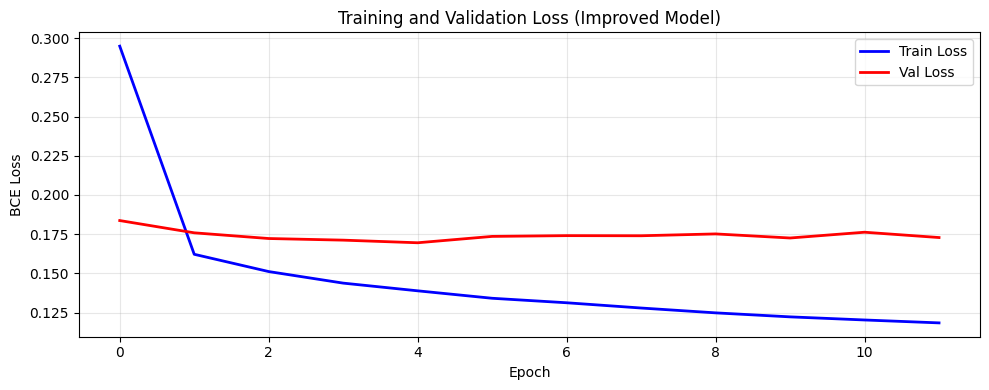

In [8]:
# ============================================
# IMPROVED TRAINING WITH COSINE ANNEALING
# ============================================

model = HybridFireGNN(in_channels=12, hidden_dim=64, dropout=0.3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

# Higher pos_weight to push recall
pos_weight = torch.tensor([8.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Cosine annealing scheduler
NUM_EPOCHS = 25
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

best_val_loss = float('inf')
patience = 7
patience_counter = 0
train_losses, val_losses = [], []

print("="*60)
print(" TRAINING: Improved Hybrid ResGNN-UNet")
print(" - 3 GAT layers with residual connection")
print(" - Dropout 0.3 in decoder")
print(" - pos_weight=8.0, AdamW, Cosine LR")
print("="*60)

for epoch in range(NUM_EPOCHS):
    # --- Training Phase ---
    model.train()
    epoch_train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y = (y > 0.0).float()
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y = (y > 0.0).float()
            logits = model(x)
            loss = criterion(logits, y)
            epoch_val_loss += loss.item()
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Step scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Save best model + early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
        marker = " ★ Best"
    else:
        patience_counter += 1
        marker = ""
    
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | LR: {current_lr:.2e}{marker}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
        break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("\n Loaded best model (lowest validation loss)")

# Plot learning curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(val_losses, 'r-', label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training and Validation Loss (Improved Model)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

Finding optimal threshold on VALIDATION set...
Optimal threshold on validation set: 0.60 (F1=0.404)

Evaluating on TEST SET with threshold=0.60...

 FINAL TEST SET RESULTS
Model                        |    IoU |  Recall |   Prec |     F1 |  AUPRC
----------------------------------------------------------------------
Persistence Baseline         |  0.013 |   0.307 |  0.014 |  0.026 |    ---
Ours (thresh=0.5)            |  0.206 |     --- |    --- |  0.342 |    ---
Ours (thresh={threshold:.2f}) |  0.226 |   0.515 |  0.286 |  0.368 |  0.277

ROC-AUC: 0.951
Test samples: 11,395,072 pixels from 2782 tiles


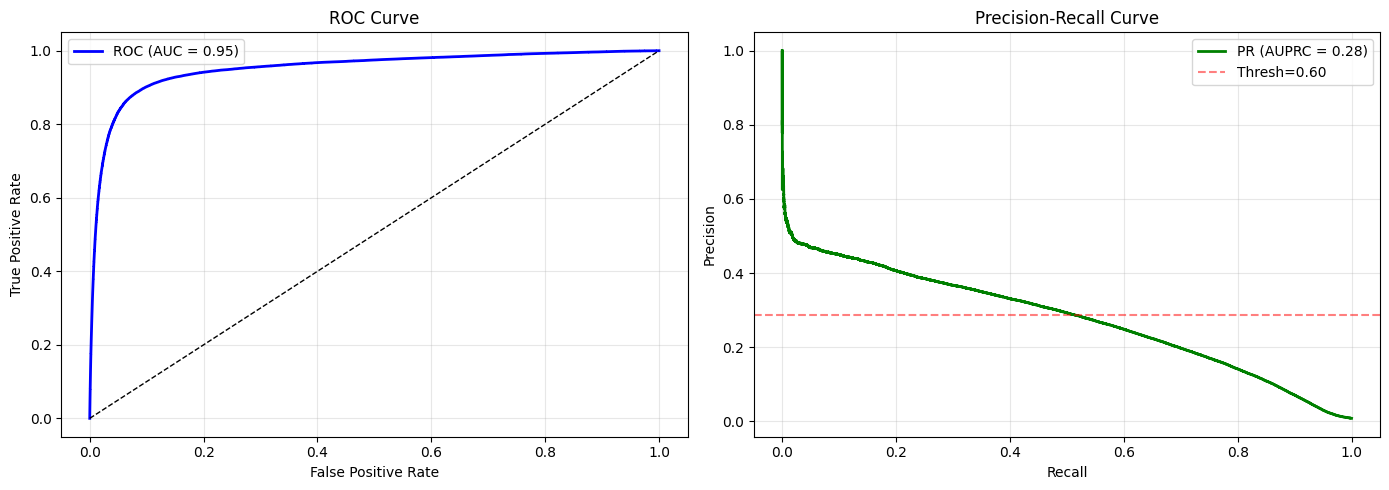

In [9]:
# ============================================
# THRESHOLD SELECTION ON VALIDATION SET 
# ============================================

def find_optimal_threshold(model, val_loader, device):
    """Find optimal threshold on VALIDATION set"""
    model.eval()
    
    all_probs = []
    all_targets = []
    
    print("Finding optimal threshold on VALIDATION set...")
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            y_bin = (y > 0.0).float()
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_targets.extend(y_bin.cpu().numpy().flatten())
    
    y_true = np.array(all_targets)
    y_prob = np.array(all_probs)
    
    from sklearn.metrics import f1_score
    
    thresholds = np.arange(0.2, 0.7, 0.05)
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in thresholds:
        y_pred_t = (y_prob > thresh).astype(float)
        f1_t = f1_score(y_true, y_pred_t, zero_division=0)
        if f1_t > best_f1:
            best_f1 = f1_t
            best_thresh = thresh
    
    print(f"Optimal threshold on validation set: {best_thresh:.2f} (F1={best_f1:.3f})")
    return best_thresh


# ============================================
# FINAL TEST SET EVALUATION (USING VAL-SET THRESHOLD)
# ============================================

def evaluate_on_test_set(model, test_loader, device, threshold):
    """Proper evaluation with FIXED threshold from validation set."""
    model.eval()
    
    all_probs = []
    all_targets = []
    baseline_preds = []
    
    print(f"\nEvaluating on TEST SET with threshold={threshold:.2f}...")
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            y_bin = (y > 0.0).float()
            
            all_probs.extend(probs.cpu().numpy().flatten())
            all_targets.extend(y_bin.cpu().numpy().flatten())
            
            # Persistence baseline (PrevFireMask is channel 11)
            prev_fire = x[:, 11:12, :, :]
            baseline_preds.extend((prev_fire > 0.0).float().cpu().numpy().flatten())
    
    y_true = np.array(all_targets)
    y_prob = np.array(all_probs)
    y_base = np.array(baseline_preds)
    
    from sklearn.metrics import (confusion_matrix, roc_auc_score, 
                                 average_precision_score, jaccard_score,
                                 precision_recall_fscore_support, roc_curve, 
                                 precision_recall_curve)
    
    # Use FIXED threshold from validation set
    y_pred = (y_prob > threshold).astype(float)
    
    # Core metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    iou = jaccard_score(y_true, y_pred, zero_division=0)
    auprc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    # Baseline metrics
    b_iou = jaccard_score(y_true, y_base, zero_division=0)
    b_prec, b_rec, b_f1, _ = precision_recall_fscore_support(y_true, y_base, average='binary', zero_division=0)
    
    # Also compute at default 0.5 threshold for comparison
    y_pred_05 = (y_prob > 0.5).astype(float)
    _, _, f1_05, _ = precision_recall_fscore_support(y_true, y_pred_05, average='binary', zero_division=0)
    iou_05 = jaccard_score(y_true, y_pred_05, zero_division=0)
    
    # Print Results
    print("\n" + "="*70)
    print(" FINAL TEST SET RESULTS")
    print("="*70)
    print(f"{'Model':<28} | {'IoU':>6} | {'Recall':>7} | {'Prec':>6} | {'F1':>6} | {'AUPRC':>6}")
    print("-"*70)
    print(f"{'Persistence Baseline':<28} | {b_iou:>6.3f} | {b_rec:>7.3f} | {b_prec:>6.3f} | {b_f1:>6.3f} | {'---':>6}")
    print(f"{'Ours (thresh=0.5)':<28} | {iou_05:>6.3f} | {'---':>7} | {'---':>6} | {f1_05:>6.3f} | {'---':>6}")
    print(f"{'Ours (thresh={threshold:.2f})':<28} | {iou:>6.3f} | {recall:>7.3f} | {precision:>6.3f} | {f1:>6.3f} | {auprc:>6.3f}")
    print("="*70)
    print(f"\nROC-AUC: {roc_auc:.3f}")
    print(f"Test samples: {len(y_true):,} pixels from {len(test_loader.dataset)} tiles")
    
    # Plot curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    axes[0].plot([0,1], [0,1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # PR Curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
    axes[1].plot(rec_curve, prec_curve, 'g-', lw=2, label=f'PR (AUPRC = {auprc:.2f})')
    axes[1].axhline(y=precision, color='r', linestyle='--', alpha=0.5, label=f'Thresh={threshold:.2f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {
        'iou': iou, 'recall': recall, 'precision': precision, 
        'f1': f1, 'auprc': auprc, 'roc_auc': roc_auc,
        'threshold': threshold
    }

# Step 1: Find threshold on validation set
optimal_threshold = find_optimal_threshold(model, val_loader, device)

# Step 2: Evaluate on test set with that fixed threshold
results = evaluate_on_test_set(model, test_loader, device, optimal_threshold)

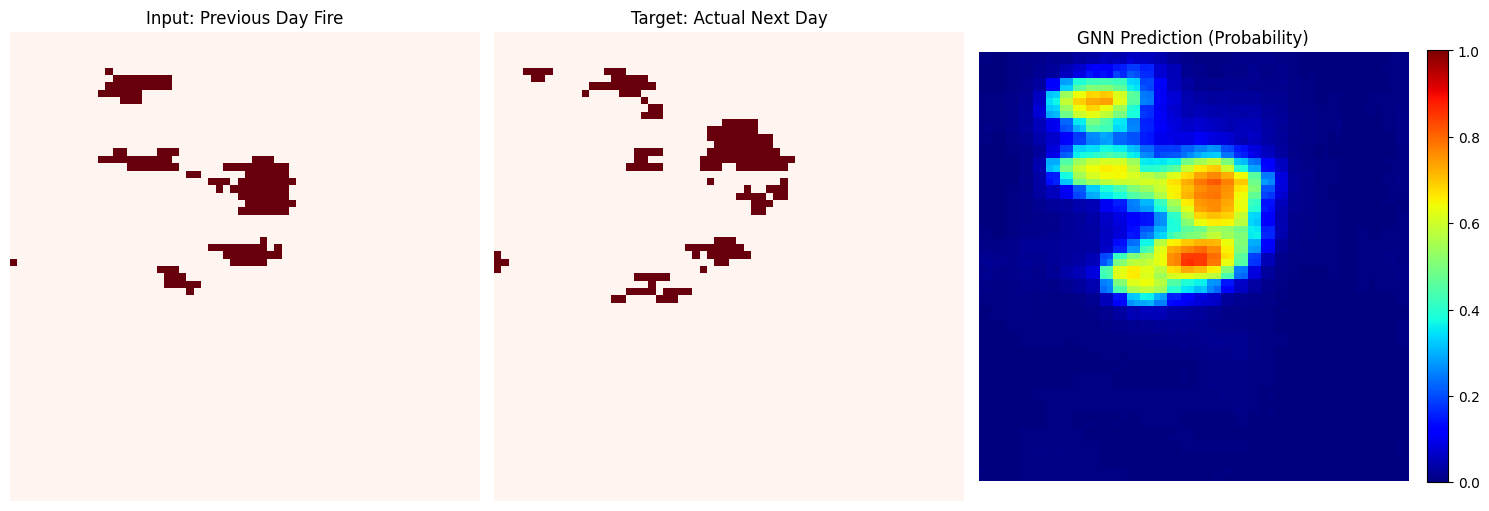

In [10]:
# ============================================
# PREDICTION VISUALIZATION (ON TEST SET)
# ============================================

def visualize_prediction(model, loader, device):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    
    with torch.no_grad():
        logits = model(x)
        pred = torch.sigmoid(logits)
    
    # First sample in batch
    input_fire = x[0, 11, :, :].cpu().numpy()  # PrevFireMask
    target_fire = y[0, 0, :, :].cpu().numpy()
    predicted_fire = pred[0, 0, :, :].cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(input_fire, cmap='Reds', vmin=0, vmax=1)
    axes[0].set_title("Input: Previous Day Fire")
    axes[0].axis('off')
    
    axes[1].imshow(target_fire, cmap='Reds', vmin=0, vmax=1)
    axes[1].set_title("Target: Actual Next Day")
    axes[1].axis('off')
    
    im = axes[2].imshow(predicted_fire, cmap='jet', vmin=0, vmax=1)
    axes[2].set_title("GNN Prediction (Probability)")
    axes[2].axis('off')
    
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig('prediction_sample.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run on TEST set
visualize_prediction(model, test_loader, device)

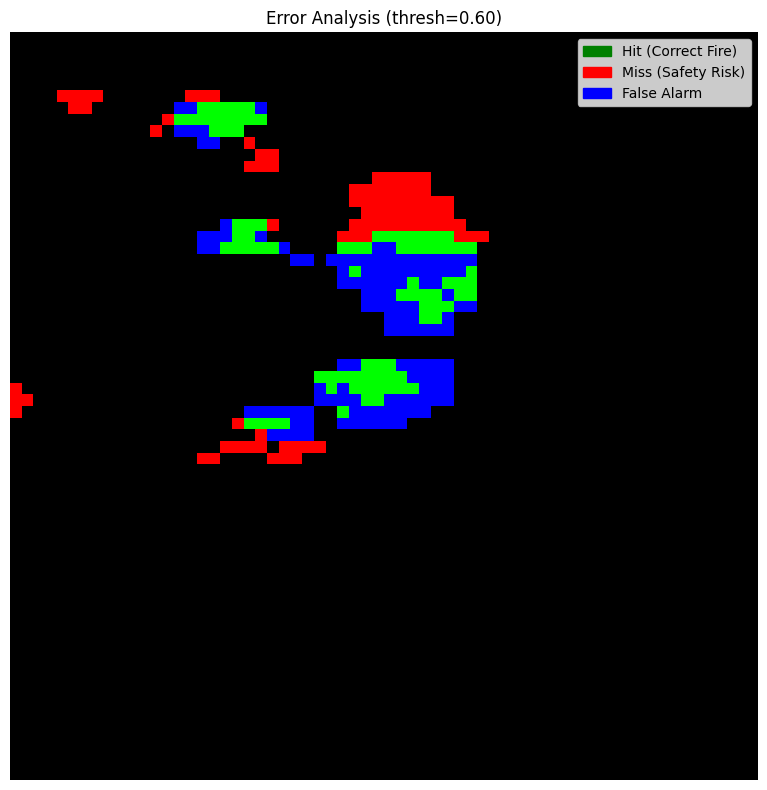

In [11]:
# ============================================
# QUALITATIVE ERROR VISUALIZATION (ON TEST SET)
# ============================================
import matplotlib.patches as mpatches

def visualize_error_map(model, loader, device, threshold=0.5):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()
        
    target = (y[0, 0, :, :] > 0.0).cpu().numpy()
    pred = preds[0, 0, :, :].cpu().numpy()
    
    H, W = target.shape
    rgb = np.zeros((H, W, 3))
    
    # Hit (Green): Correct fire prediction
    hit = (target == 1) & (pred == 1)
    rgb[hit] = [0, 1, 0] 
    
    # Miss (Red): Missed fire (safety risk)
    miss = (target == 1) & (pred == 0)
    rgb[miss] = [1, 0, 0]
    
    # False Alarm (Blue): Over-prediction
    fa = (target == 0) & (pred == 1)
    rgb[fa] = [0, 0, 1]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(rgb)
    ax.set_title(f"Error Analysis (thresh={threshold:.2f})", fontsize=12)
    ax.axis('off')
    
    legend_elements = [
        mpatches.Patch(color='green', label='Hit (Correct Fire)'),
        mpatches.Patch(color='red', label='Miss (Safety Risk)'),
        mpatches.Patch(color='blue', label='False Alarm')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run on TEST set with optimal threshold
visualize_error_map(model, test_loader, device, threshold=optimal_threshold)